In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [12]:
import pandas as pd
hemb = pd.read_csv("../../data/output/pred_simple_spatial_embeddings.csv")
df_pred = pd.read_csv("../../data/transactions_simple_spatial_pred.csv")

In [13]:
df_pred.head()

,client_id,cluster,timestamp,importo,merchant,cocau
0,0,cluster_3,1577872199,23.023202,Spotify,224
1,0,cluster_3,1582593520,55.901436,H&M,76
2,0,cluster_3,1583004771,35.116854,Starbucks,140
3,0,cluster_3,1583945897,66.859541,IKEA,39
4,0,cluster_3,1585401612,64.699848,Decathlon,11


In [14]:
hemb.head()

,client_id,client_code,window_index,window_start_ts,window_end_ts,emb_0,emb_1,emb_2,emb_3,emb_4,...,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,window_start,window_end
0,0,0,0,1577872199,1608748046,-0.042807,-0.060454,-0.639664,-0.398074,0.223261,...,0.751733,-0.321625,0.644876,-1.941897,2.094387,0.937137,1.973018,-0.029646,2020-01-01 09:49:59+00:00,2020-12-23 18:27:26+00:00
1,0,0,1,1592342005,1623457518,-0.316313,0.152186,-0.647654,-0.220369,0.018909,...,0.848092,-0.506084,0.765307,-2.025288,2.141092,0.731479,2.045963,0.296237,2020-06-16 21:13:25+00:00,2021-06-12 00:25:18+00:00
2,0,0,2,1606316001,1639884214,0.236630,-0.484383,-0.483972,-0.212822,0.447212,...,0.433653,0.068368,0.213105,-1.652753,2.171316,0.853401,1.970730,0.312736,2020-11-25 14:53:21+00:00,2021-12-19 03:23:34+00:00
3,0,0,3,1619629315,1648515022,-0.812944,-0.214620,-0.827016,0.446094,0.542217,...,0.704585,0.014198,0.580502,-2.392504,2.274814,1.427081,2.136792,0.543573,2021-04-28 17:01:55+00:00,2022-03-29 00:50:22+00:00
4,0,0,4,1637496919,1659458008,-0.387693,0.016751,-1.043655,-0.117546,-0.111370,...,0.172724,0.213635,1.156832,-1.763446,1.615926,0.893516,2.114781,0.978221,2021-11-21 12:15:19+00:00,2022-08-02 16:33:28+00:00


In [15]:
# prendi l'ultimo embedding per ogni client_id prendendo il windows slot più grande
hemb_last = hemb.groupby("client_id").last().reset_index()

In [16]:
map_client_id = df_pred[["client_id", "cluster"]].drop_duplicates()

In [17]:
map_client_id

,client_id,cluster
0,0,cluster_3
104,1,cluster_2
232,2,cluster_2
346,3,cluster_2
447,4,cluster_4
...,...,...
479409,3995,cluster_2
479586,3996,cluster_4
479698,3997,cluster_2
479812,3998,cluster_2


In [18]:
hemb_last = hemb_last.merge(map_client_id, on="client_id", how="left")

In [19]:
map_client_id

,client_id,cluster
0,0,cluster_3
104,1,cluster_2
232,2,cluster_2
346,3,cluster_2
447,4,cluster_4
...,...,...
479409,3995,cluster_2
479586,3996,cluster_4
479698,3997,cluster_2
479812,3998,cluster_2


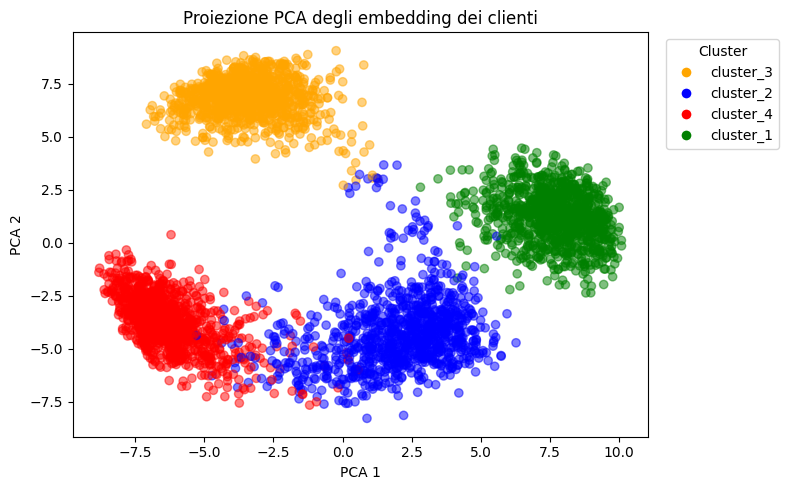

In [20]:
# proietta gli embedding in 2D con PCA usando emb_0,...,emb_127
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

colors_map = {
    "cluster_3": "orange",
    "cluster_1": "green",
    "cluster_2": "blue",
    "cluster_4": "red",
}

emb_cols = [f"emb_{i}" for i in range(128)]

# rimuovi righe senza cluster
plot_df = hemb_last.dropna(subset=["cluster"]).copy()

pca = PCA(n_components=2, random_state=42)
hemb_last_pca = pca.fit_transform(plot_df[emb_cols])

# colore PER OGNI PUNTO (non per cluster unico)
point_colors = plot_df["cluster"].map(colors_map).fillna("gray")

plt.figure(figsize=(8, 5))
plt.scatter(
    hemb_last_pca[:, 0],
    hemb_last_pca[:, 1],
    alpha=0.5,
    c=point_colors
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Proiezione PCA degli embedding dei clienti")

# legenda
cluster_names = plot_df["cluster"].dropna().unique()
handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=colors_map.get(name, "gray"),
               markersize=8, label=name)
    for name in cluster_names
]
plt.legend(handles=handles, title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()